# Reinforcement Learning – Practice Exercises

- Id: 22302421
- Full name: Nguyễn Phúc Minh Châu

This notebook is designed for students to practice and experiment with Reinforcement Learning methods.

Topics covered:
- Q-Learning
- Approximate Q-Learning
- Policy Search

Students are expected to modify, complete, and extend the code by themselves.

## Environment Setup

### Environment Description
- Grid size: 3x3 (states 0 to 8)
- Start state: 0
- Terminal state: 8
- Obstacle state: 4, 5 (cannot enter)
- Actions: 0=up, 1=down, 2=left, 3=right
- Reward: -1 per step, +10 at terminal state

Tasks:
- Re-implement the environment dynamics.
- Clearly comment your code.
- Verify that the terminal state and obstacle behave correctly.

In [ ]:
# TODO: Implement the Grid World environment here
# - Define states, actions, rewards
# - Implement the step(state, action) function
# - Add comments explaining each part

import random
import math

num_states = 9
num_actions = 4  # up, down, left, right
terminal_state = 8
obstacle_state = (4, 5)

def step(state, action):
    if state == terminal_state:
        return state, 0

    row, col = divmod(state, 3)

    if action == 0: row -= 1       # UP
    elif action == 1: row += 1     # DOWN
    elif action == 2: col -= 1     # LEFT
    elif action == 3: col += 1     # RIGHT

    # Kiểm tra biên
    if row < 0 or row > 2 or col < 0 or col > 2:
        return state, -1

    next_state = row * 3 + col

    if next_state == obstacle_state:
        return state, -1

    if next_state == terminal_state:
        return next_state, 10

    return next_state, -1

## Exercise 1: Q-Learning

Tasks:
- Implement tabular Q-Learning.
- Use epsilon-greedy for action selection.
- Train the agent until it reaches the terminal state reliably.
- Apply the learned policy.

Questions:
- How does epsilon affect exploration?
- What happens if the learning rate is too large or too small?

In [6]:
# TODO: Implement Q-Learning here
# - Initialize Q-table
# - Implement epsilon-greedy action selection
# - Update Q-values
# - Apply the learned policy

alpha = 0.1
gamma = 0.9
epsilon = 0.2

Q = [[0 for _ in range(num_actions)] for _ in range(num_states)]

def choose_action(state):
    if random.random() < epsilon:
        return random.randint(0, num_actions - 1)
    else:
        return max(range(num_actions), key=lambda a: Q[state][a])

def update_Q(state, action, reward, next_state):
    best_next_Q = max(Q[next_state])
    Q[state][action] += alpha * (reward + gamma * best_next_Q - Q[state][action])


for episode in range(30):
    state = 0  # Start state
    while state != terminal_state:
        action = choose_action(state)
        next_state, reward = step(state, action)
        update_Q(state, action, reward, next_state)
        state = next_state

policy = []

for s in range(num_states):
    best_action = Q[s].index(max(Q[s]))
    policy.append(best_action)

state = 0
trajectory = [state]
actions = []

while state != terminal_state:
    action = policy[state]

    state, _ = step(state, action)
    trajectory.append(state)
    actions.append(action)

print("Agent trajectory:", trajectory)
print("Sequence of actions:", actions)

Agent trajectory: [0, 1, 4, 7, 8]
Sequence of actions: [3, 1, 1, 3]


## Exercise 2: Approximate Q-Learning

Tasks:
- Replace the Q-table with a linear function approximator.
- Design a feature representation for (state, action).
- Update the weight vector using the TD error.
- Apply the learned policy.

Questions:
- How does feature design affect learning?
- Why can Approximate Q-Learning generalize better than tabular Q-Learning?

In [ ]:
# TODO: Implement Approximate Q-Learning here
# - Define feature function f(state, action)
# - Define Q(s,a) = w · f(s,a)
# - Update weights using TD error
# - Apply the learned policy

def feature_function(state, action):
    f = [0] * (num_states * num_actions)
    f[state * num_actions + action] = 1
    return f

weights = [0] * (num_states * num_actions)

def approximate_Q(state, action):
    features = feature_function(state, action)
    return sum(w * f for w, f in zip(weights, features))

for episode in range(30):
    state = 0  # Start state
    while state != terminal_state:
        action = choose_action(state)
        next_state, reward = step(state, action)

        features = feature_function(state, action)
        best_next_Q = max(approximate_Q(next_state, a) for a in range(num_actions))
        td_error = reward + gamma * best_next_Q - approximate_Q(state, action)

        for i in range(len(weights)):
            weights[i] += alpha * td_error * features[i]

        state = next_state

approx_policy = []
for s in range(num_states):
    best_action = max(range(num_actions), key=lambda a: approximate_Q(s, a))
    approx_policy.append(best_action)
state = 0
approx_trajectory = [state]
approx_actions = []

while state != terminal_state:
    action = approx_policy[state]
    state, _ = step(state, action)
    approx_trajectory.append(state)
    approx_actions.append(action)
print("Approximate Q-Learning trajectory:", approx_trajectory)
print("Approximate Q-Learning actions:", approx_actions)

Approximate Q-Learning trajectory: [0, 1, 4, 7, 8]
Approximate Q-Learning actions: [3, 1, 1, 3]


## Exercise 3: Policy Search

Tasks:
- Implement a stochastic policy using softmax.
- Maintain a table of preferences.
- Update the policy using the REINFORCE rule.
- Apply the learned policy.

Questions:
- Why does a stochastic policy provide exploration naturally?
- What causes high variance in policy gradient methods?

In [10]:
# TODO: Implement Policy Search (REINFORCE) here
# - Initialize preferences
# - Implement softmax policy
# - Sample actions according to probabilities
# - Update preferences after each episode
# - Apply the learned policy

preferences = [[0 for _ in range(num_actions)] for _ in range(num_states)]

def softmax(state):
    exp_prefs = [math.exp(p) for p in preferences[state]]
    sum_exp_prefs = sum(exp_prefs)
    return [exp_pref / sum_exp_prefs for exp_pref in exp_prefs]

def choose_action_policy_search(state):
    action_probs = softmax(state)
    return random.choices(range(num_actions), weights=action_probs)[0]

for episode in range(30):
    state = 0  # Start state
    trajectory = []
    rewards = []

    while state != terminal_state:
        action = choose_action_policy_search(state)
        next_state, reward = step(state, action)

        trajectory.append((state, action))
        rewards.append(reward)

        state = next_state

    G = 0
    for t in reversed(range(len(trajectory))):
        G = rewards[t] + gamma * G
        state, action = trajectory[t]
        preferences[state][action] += alpha * G

policy_search_policy = []
for s in range(num_states):
    best_action = max(range(num_actions), key=lambda a: preferences[s][a])
    policy_search_policy.append(best_action)

state = 0
policy_search_trajectory = [state]
policy_search_actions = []

while state != terminal_state:
    action = policy_search_policy[state]
    state, _ = step(state, action)
    policy_search_trajectory.append(state)
    policy_search_actions.append(action)
    
print("Policy Search trajectory:", policy_search_trajectory)
print("Policy Search actions:", policy_search_actions)

Policy Search trajectory: [0, 3, 6, 7, 8]
Policy Search actions: [1, 1, 3, 3]


## Exercise 4: Comparison and Reflection

Answer the following questions in your own words:

- Which method learns fastest in this environment?

    Policy Search methods like REINFORCE may require more episodes to converge due to their reliance on sampling and policy updates.

- Which method is more stable?

    Q-Learning can be unstable if the learning rate is too high or if the environment is non-stationary. Approximate Q-Learning can introduce additional instability due to function approximation errors. Policy Search methods can be more stable in some cases, especially when using a well-designed policy representation and appropriate learning rates.

- Which method would scale better to larger or continuous environments?

    Policy Search methods, especially those that use function approximation (like neural networks), tend to scale better to larger or continuous environments. This is because they can generalize across states and actions, whereas Q-Learning may struggle with the curse of dimensionality in large state-action spaces. Approximate Q-Learning can also help with scaling, but it may require careful tuning of the function approximator to avoid instability.

Support your answers with observations from your experiments.

## Exercise 5: Simulate an agent operating in the environment using animation.
- The initial state is random and less than 4.
- The agen will move from the initial state to the terminal state.

Initial state: 3
Trajectory: [3, 6, 7, 8]


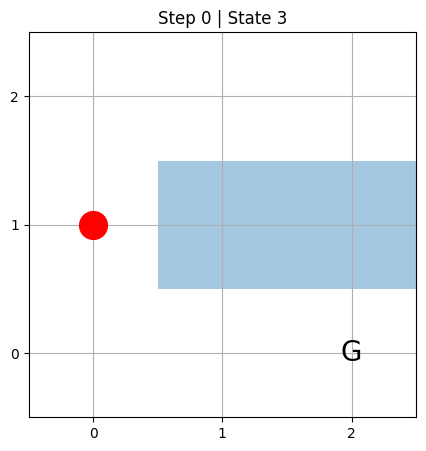

In [ ]:
# Your code here
import matplotlib.pyplot as plt


initial_state = random.randint(0, 3)

state = initial_state
trajectory = [state]

max_steps = 50

while state != terminal_state and len(trajectory) < max_steps:
    action = policy_search_policy[state]
    state, reward = step(state, action)
    trajectory.append(state)

print("Initial state:", initial_state)
print("Trajectory:", trajectory)

plt.ion()  # Interactive mode

fig, ax = plt.subplots(figsize=(5, 5))

ax.set_xlim(-0.5, 2.5)
ax.set_ylim(-0.5, 2.5)

ax.set_xticks([0, 1, 2])
ax.set_yticks([0, 1, 2])

ax.grid(True)

# Goal state
goal_row, goal_col = divmod(terminal_state, 3)

ax.text(
    goal_col,
    2 - goal_row,
    "G",
    fontsize=20,
    ha="center",
    va="center"
)

# Obstacles
for obs in [4, 5]:
    row, col = divmod(obs, 3)

    obstacle = plt.Rectangle(
        (col - 0.5, 2 - row - 0.5),
        1,
        1,
        alpha=0.4
    )

    ax.add_patch(obstacle)

# Agent marker
agent, = ax.plot([], [], 'ro', markersize=20)

for step_idx, state in enumerate(trajectory):

    row, col = divmod(state, 3)

    agent.set_data([col], [2 - row])

    ax.set_title(
        f"Step {step_idx} | State {state}"
    )

    fig.canvas.draw()
    fig.canvas.flush_events()

    plt.pause(0.5)

plt.ioff()
plt.show()
plt.show()

## Optional Challenge

Advanced tasks:
- Make the environment stochastic (actions succeed with probability 0.8).
- Add a small negative reward for hitting walls.
- Propose one improvement to reduce variance in Policy Search.

These tasks are optional but encouraged.

In [27]:
num_states = 9
num_actions = 4  
terminal_state = 8
obstacle_state = 4  
SUCCESS_PROB = 0.8  

alpha = 0.05    
alpha_v = 0.1   

preferences = [[0.0 for _ in range(num_actions)] for _ in range(num_states)]
V = [0.0 for _ in range(num_states)]

def softmax(action_preferences):
    max_val = max(action_preferences)  
    exp_vals = [math.exp(p - max_val) for p in action_preferences]
    total = sum(exp_vals)
    return [v / total for v in exp_vals]

def policy(state):
    return softmax(preferences[state])

def choose_action(state):
    probs = policy(state)
    r = random.random()
    cumulative_prob = 0.0
    for action, prob in enumerate(probs):
        cumulative_prob += prob
        if r <= cumulative_prob:
            return action
    return num_actions - 1

def step(state, action):
    if state == terminal_state:
        return state, 0

    if random.random() > SUCCESS_PROB:
        other_actions = [a for a in range(num_actions) if a != action]
        action = random.choice(other_actions)

    row, col = divmod(state, 3)

    if action == 0:      
        row -= 1
    elif action == 1:    
        row += 1
    elif action == 2:    
        col -= 1
    elif action == 3:    
        col += 1

    if row < 0 or row > 2 or col < 0 or col > 2:
        return state, -2

    next_state = row * 3 + col

    if next_state == obstacle_state:
        return state, -2

    if next_state == terminal_state:
        return next_state, 10

    return next_state, -1

for episode in range(500):  
    state = 0
    trajectory = []
    rewards = []
    step_count = 0
    
    while state != terminal_state and step_count < 100:
        action = choose_action(state)
        next_state, reward = step(state, action)
        trajectory.append((state, action))
        rewards.append(reward)
        state = next_state
        step_count += 1
    
    G = sum(rewards)
    
    for (state, action) in trajectory:
        advantage = G - V[state]
        V[state] += alpha_v * (G - V[state])
        
        probs = policy(state)
        for a in range(num_actions):
            if a == action:
                preferences[state][a] += alpha * advantage * (1 - probs[a])
            else:
                preferences[state][a] -= alpha * advantage * probs[a]

state = 0
trajectory = [state]
actions = []
steps = 0
action_names = ["UP", "DOWN", "LEFT", "RIGHT"]

while state != terminal_state and steps < 20:
    probs = policy(state)
    action = probs.index(max(probs))
    state, _ = step(state, action)
    trajectory.append(state)
    actions.append(action_names[action])
    steps += 1
    
print("Agent trajectory:", trajectory)
print("Sequence of actions:", actions)

Agent trajectory: [0, 3, 6, 7, 8]
Sequence of actions: ['DOWN', 'DOWN', 'RIGHT', 'RIGHT']
